# 룰 비교 실험 (FIFO / SPT / random / QSPT)
## 환경 설정

In [25]:
import os
import simpy
import random
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

load_dotenv()

BASE_DATA_PATH    = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD  = os.getenv('PM_HAZARD_THRESHOLD', '0.2')
QTIME_URGENCY_FACTOR = os.getenv('QTIME_URGENCY_FACTOR', '1.5')
os.environ['QTIME_URGENCY_FACTOR'] = str(QTIME_URGENCY_FACTOR)


##  .env 파일 MACHINE_CHOICE를 주석처리하고 실행해야 오류 안납니다.
##         # MACHINE_CHOICE=(random / FIFO / SPT / QSPT)

## 모듈 import

In [26]:
from utils import DataLoader, EventLogger
from simulation import Scheduler

## 데이터 로드

In [27]:
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} 개 / Operations: {len(data['operations'])} 개 / Machines: {len(data['machines'])} 개")

Jobs: 10 개 / Operations: 35 개 / Machines: 8 개


## 룰 비교 실험

In [28]:
def run_simulation(rule: str, seed: int = 42) -> dict:
    random.seed(seed)
    os.environ['MACHINE_CHOICE'] = rule

    _env = simpy.Environment()
    _logger = EventLogger(_env)
    _scheduler = Scheduler(
        env=_env,
        data=data,
        event_logger=_logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD),
        qtime_urgency_factor=float(QTIME_URGENCY_FACTOR),
    )
    _env.run(until=_scheduler.job_chk_process)

    completed, due_ok = 0, 0
    for job in _scheduler._Scheduler__jobs:
        completed += int(job.completed_time > 0.0)
        due_ok    += int(job.is_in_due_date())

    df_log = pd.DataFrame(_logger.logs)
    qtime_map = data['operations'].set_index('op_id')['qtime']
    waiting = (
        df_log[(df_log['resource'] == 'job') & (df_log['op_id'].notna()) & (df_log['event'] == 'waiting')]
        .groupby(['id', 'op_id'])['start'].min().reset_index().rename(columns={'id': 'job_id', 'start': 'waiting_start'})
    )
    working = (
        df_log[(df_log['resource'] == 'job') & (df_log['op_id'].notna()) & (df_log['event'] == 'working')]
        .groupby(['id', 'op_id'])['start'].max().reset_index().rename(columns={'id': 'job_id', 'start': 'working_start'})
    )
    qc = waiting.merge(working, on=['job_id', 'op_id'], how='inner')
    qc['actual_wait'] = qc['working_start'] - qc['waiting_start']
    qc['qtime_limit'] = qc['op_id'].map(qtime_map)
    qc['violation']   = (qc['actual_wait'] - qc['qtime_limit']).clip(lower=0)
    qtime_total = round(qc['violation'].sum(), 3)

    return {
        'rule':            rule,
        'makespan':        round(_env.now, 3),
        'completed_jobs':  completed,
        'due_date_met':    due_ok,
        'qtime_violation': qtime_total,
    }

RULES   = ['FIFO', 'SPT', 'random', 'QSPT']
SEEDS   = [42, 123, 456, 789, 1000]

rows = []
for rule in RULES:
    for seed in SEEDS:
        row = run_simulation(rule, seed)
        row['seed'] = seed
        rows.append(row)

df_all = pd.DataFrame(rows)
display(df_all)

,rule,makespan,completed_jobs,due_date_met,qtime_violation,seed
0,FIFO,128.000,10,10,54.000,42
1,FIFO,157.208,10,9,195.963,123
2,FIFO,176.786,10,8,206.387,456
3,FIFO,140.000,10,10,54.000,789
4,FIFO,169.831,10,10,136.662,1000
5,SPT,147.000,10,10,153.000,42
6,SPT,159.775,10,10,194.245,123
7,SPT,167.411,10,8,94.331,456
8,SPT,181.481,10,9,195.481,789
9,SPT,148.000,10,10,153.000,1000


In [29]:
df_stats = df_all.groupby('rule')[['makespan', 'qtime_violation']].agg(['mean', 'std', 'min', 'max']).round(2)
print("=== 룰별 KPI 통계 ===")
display(df_stats)

=== 룰별 KPI 통계 ===


makespan                       qtime_violation                      
           mean    std    min     max            mean    std    min     max
rule                                                                       
FIFO     154.36  20.32  128.0  176.79          129.40  73.79  54.00  206.39
QSPT     155.42  16.71  142.0  183.92          101.78  44.90  44.00  138.79
SPT      160.73  14.38  147.0  181.48          158.01  41.30  94.33  195.48
random   162.51   7.29  154.9  170.38          162.31  60.94  98.18  242.79

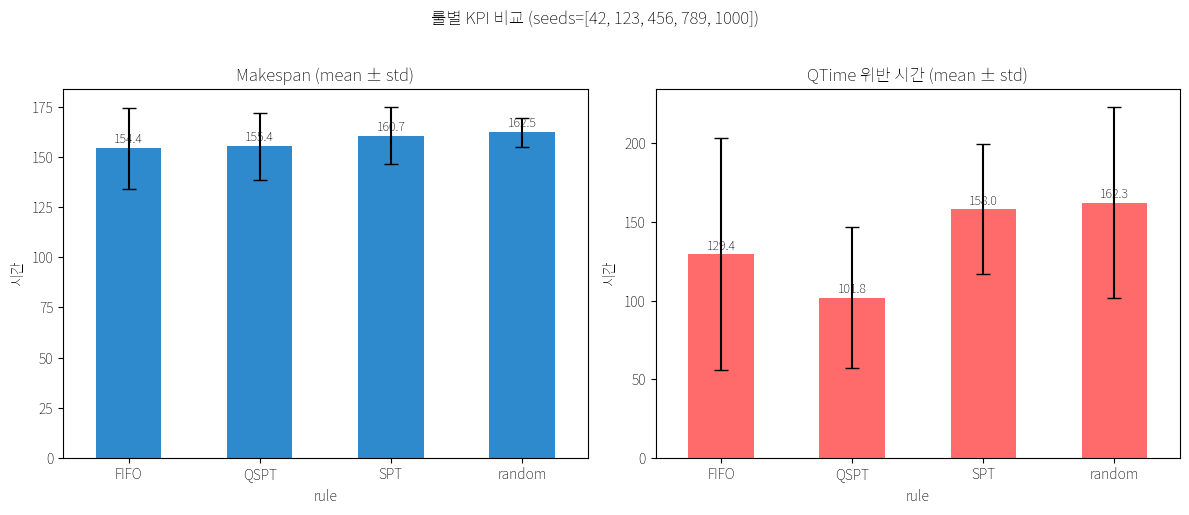

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, color, title in [
    (axes[0], 'makespan',        '#2E89CD', 'Makespan (mean ± std)'),
    (axes[1], 'qtime_violation', '#FF6B6B', 'QTime 위반 시간 (mean ± std)'),
]:
    means = df_all.groupby('rule')[col].mean()
    stds  = df_all.groupby('rule')[col].std()
    means.plot(kind='bar', ax=ax, color=color, rot=0, yerr=stds, capsize=5)
    ax.set_title(title)
    ax.set_ylabel('시간')
    for bar in ax.patches[:len(means)]:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'룰별 KPI 비교 (seeds={SEEDS})', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_25932\1445350736.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='rule', y='makespan',        ax=axes[0], palette='Blues')
C:\Users\User\AppData\Local\Temp\ipykernel_25932\1445350736.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='rule', y='qtime_violation', ax=axes[1], palette='Reds')


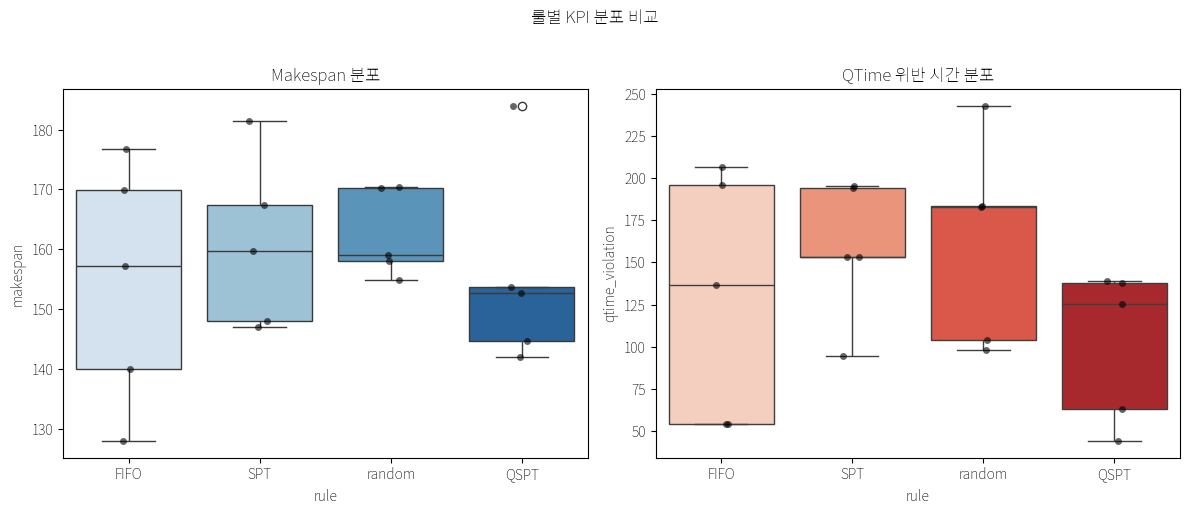

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_all, x='rule', y='makespan',        ax=axes[0], palette='Blues')
sns.boxplot(data=df_all, x='rule', y='qtime_violation', ax=axes[1], palette='Reds')
sns.stripplot(data=df_all, x='rule', y='makespan',        ax=axes[0], color='black', alpha=0.6, jitter=True)
sns.stripplot(data=df_all, x='rule', y='qtime_violation', ax=axes[1], color='black', alpha=0.6, jitter=True)

axes[0].set_title('Makespan 분포')
axes[1].set_title('QTime 위반 시간 분포')
plt.suptitle('룰별 KPI 분포 비교', y=1.02)
plt.tight_layout()
plt.show()